# Win Probability & Conformal Calibration
### Two natural outputs of a probabilistic rating system

---

Once you have a posterior over team ratings, two things fall out for free:

1. **Win probability** — a single number $P(\text{team A wins})$ derived from the full predictive distribution over the point margin.
2. **Conformal calibration** — a formal, distribution-free check that the model's stated uncertainty is accurate, not just that its point predictions are good.

This notebook demonstrates both, using Model 2 (ridge / exact Gaussian posterior) on the 2025-26 season.

## Setup

In [1]:
import sys
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict

repo = Path("../").resolve()
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import norm as _norm, kstest, gaussian_kde

from models.data import open_db, load_season_games, GameRow, parse_date
from models.model2 import Model2
from models.eval import temporal_split, win_probability, conformal_calibration_scores

# ── shared plot style ────────────────────────────────────────────────────────
BG, GRID, SPINE, TICK = "#0f0f1a", "#1a1a3a", "#333355", "#aaaacc"
C1, C2, CA = "#00bfff", "#ff6b35", "#a8ff78"

def dark_ax(ax, fig=None):
    ax.set_facecolor(BG)
    if fig: fig.patch.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_color(SPINE)
    ax.tick_params(colors=TICK, labelsize=9)
    ax.grid(color=GRID, linewidth=0.5, linestyle="--")
    ax.xaxis.label.set_color(TICK)
    ax.yaxis.label.set_color(TICK)

SEASON = 2026
conn   = open_db()
cur    = conn.cursor()

cur.execute("SELECT TeamID, School FROM teams_years WHERE year = ?", (SEASON,))
team_names = dict(cur.fetchall())

all_rows = load_season_games(conn, SEASON)

# Fit Model 2 on full season (used for win probability demonstrations)
m2_full = Model2()
m2_full.fit_rows(all_rows, SEASON)
summary = m2_full.point_summary()
top_tids = sorted(summary, key=lambda t: summary[t].net_rtg, reverse=True)[:20]

# 80/20 split for calibration evaluation
train_rows, test_rows = temporal_split(all_rows, 0.80)
m2_cal = Model2()
m2_cal.fit_rows(train_rows, SEASON)

print(f"Loaded {len(all_rows):,} observations   "
      f"({len(train_rows):,} train / {len(test_rows):,} test)")
print(f"σ_eff = {float(np.sqrt(m2_full._sigma2_eff)):.2f} pts/100  "
      f"(irreducible per-possession game noise)")

Loaded 11,510 observations   (9,208 train / 2,302 test)
σ_eff = 12.65 pts/100  (irreducible per-possession game noise)


---
## 1 · Win probability from the predictive margin

For a neutral-site game between teams $i$ and $j$ with expected possessions $p$:

$$\text{margin}^{(s)} = \left(\hat{e}_{ij}^{(s)} - \hat{e}_{ji}^{(s)}\right) \cdot \frac{p}{100}, \qquad \theta^{(s)} \sim p(\theta \mid \mathcal{D})$$

The total standard deviation combines parameter uncertainty (from posterior draws) with irreducible game noise (two independent scoring halves, each with $\sigma_{\text{eff}}$):

$$\sigma_{\text{margin}} = \sqrt{\text{Var}(\text{margin}^{(s)}) + 2 \cdot \sigma_{\text{eff}}^2 \cdot (p/100)^2}$$

$$P(i \text{ wins}) = \Phi\!\left(\frac{\overline{\text{margin}}}{\sigma_{\text{margin}}}\right)$$

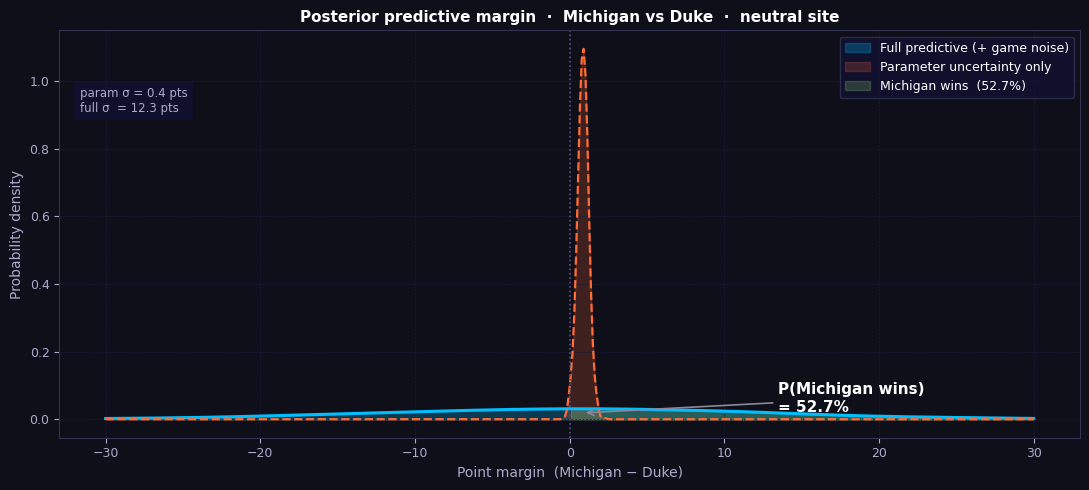

Expected margin: +0.9 pts  (σ_param=0.4,  σ_total=12.3)
P(Michigan wins) = 0.527


In [2]:
# ── Build the full margin distribution for the #1 vs #2 matchup ──────────────
t1, t2 = top_tids[0], top_tids[1]
n1, n2 = team_names.get(t1, str(t1)), team_names.get(t2, str(t2))
POSS   = 70.0
scale  = POSS / 100.0

rng = np.random.default_rng(42)
draws = m2_full.sample_posterior(1000, rng)

row_t1 = GameRow(game_id=0, season=SEASON, team_id=t1, opp_id=t2, pts=0, poss=POSS, h=0)
row_t2 = GameRow(game_id=0, season=SEASON, team_id=t2, opp_id=t1, pts=0, poss=POSS, h=0)

margin_param = np.array([
    (m2_full._predict_from_theta(th, [row_t1])[0]
     - m2_full._predict_from_theta(th, [row_t2])[0]) * scale
    for th in draws
])  # parameter uncertainty only

sigma_eff_pts = float(np.sqrt(m2_full._sigma2_eff)) * scale
noise = np.random.default_rng(1).normal(0, np.sqrt(2) * sigma_eff_pts, len(draws))
margin_full = margin_param + noise  # full predictive (includes game noise)

p_win = win_probability(m2_full, t1, t2, h=0, poss=POSS, n_draws=1000,
                        rng=np.random.default_rng(42))

# ── Plot ─────────────────────────────────────────────────────────────────────
xs = np.linspace(-30, 30, 500)
kde_param = gaussian_kde(margin_param, bw_method=0.35)
kde_full  = gaussian_kde(margin_full,  bw_method=0.35)

fig, ax = plt.subplots(figsize=(11, 5))
dark_ax(ax, fig)

ax.fill_between(xs, kde_full(xs), alpha=0.25, color=C1, label="Full predictive (+ game noise)")
ax.plot(xs, kde_full(xs), color=C1, lw=2.2)
ax.fill_between(xs, kde_param(xs), alpha=0.20, color=C2, label="Parameter uncertainty only")
ax.plot(xs, kde_param(xs), color=C2, lw=1.6, linestyle="--")

ax.axvline(0, color="#555577", lw=1.2, linestyle=":")
ax.fill_between(xs, kde_full(xs), where=(xs > 0), alpha=0.18, color=CA,
                label=f"{n1} wins  ({p_win:.1%})")

# Annotate
ax.annotate(
    f"P({n1} wins)\n= {p_win:.1%}",
    xy=(margin_param.mean(), kde_full(margin_param.mean())[0] * 0.6),
    xytext=(max(xs)*0.45, kde_full(xs).max() * 0.70),
    color="white", fontsize=11, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#888899", lw=1.2),
)
ax.annotate(
    f"param σ = {margin_param.std():.1f} pts\nfull σ  = {margin_full.std():.1f} pts",
    xy=(0.02, 0.80), xycoords="axes fraction",
    color="#aaaacc", fontsize=8.5,
    bbox=dict(fc="#111133", ec="none", alpha=0.75),
)

ax.set_xlabel(f"Point margin  ({n1} − {n2})")
ax.set_ylabel("Probability density")
ax.set_title(
    f"Posterior predictive margin  ·  {n1} vs {n2}  ·  neutral site",
    color="white", fontsize=11, fontweight="bold",
)
ax.legend(labelcolor="white", facecolor="#111133", edgecolor=SPINE, fontsize=9)
plt.tight_layout()
plt.show()

print(f"Expected margin: {margin_param.mean():+.1f} pts  "
      f"(σ_param={margin_param.std():.1f},  σ_total={margin_full.std():.1f})")
print(f"P({n1} wins) = {p_win:.3f}")

---
## 2 · Win probability matrix — top 12 teams

Every cell $(i, j)$ is $P(\text{row team beats column team})$ at a neutral site with 70 possessions.  
The diagonal is 0.50 by definition; symmetry holds: $P(i > j) + P(j > i) = 1$.

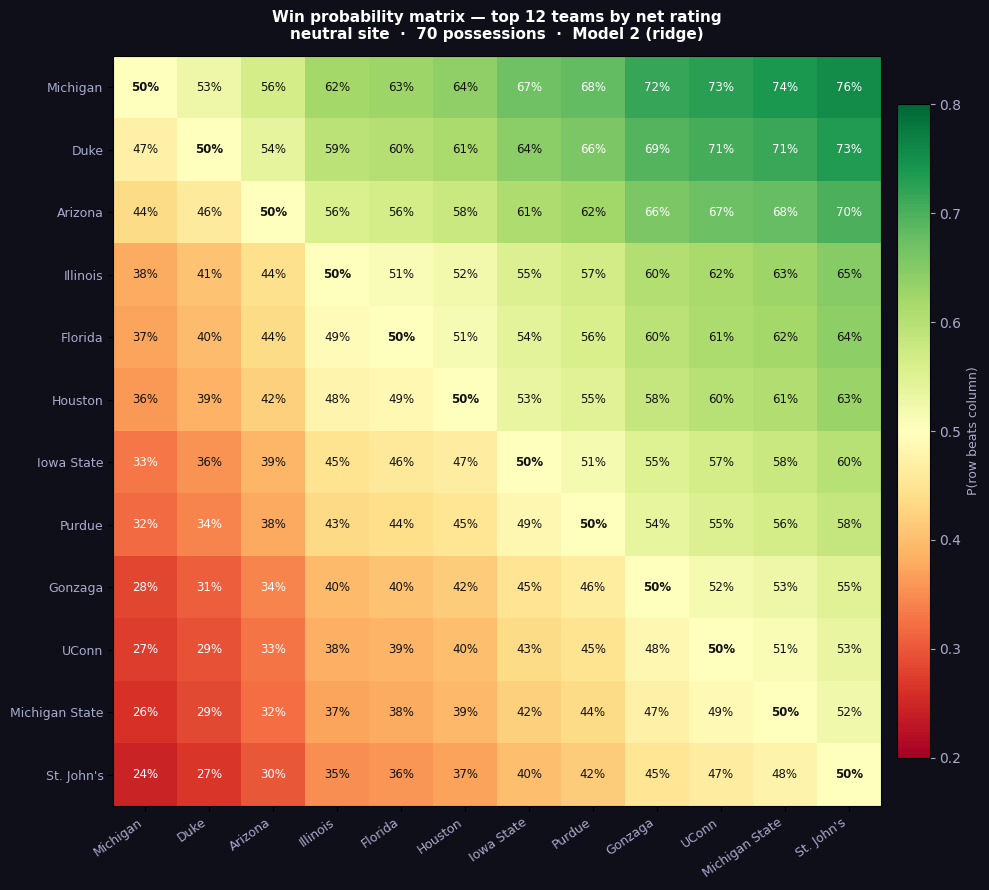

Team                       Avg P(win) vs top-12
------------------------------------------------
  Michigan                66.1%
  Duke                    63.4%
  Arizona                 59.5%
  Illinois                53.4%
  Florida                 52.6%
  Houston                 51.3%
  Iowa State              47.8%
  Purdue                  46.2%
  Gonzaga                 42.3%
  UConn                   40.7%
  Michigan State          39.6%
  St. John's              37.3%


In [3]:
TOP = 12
tids   = top_tids[:TOP]
labels = [team_names.get(t, str(t)) for t in tids]

rng_hm = np.random.default_rng(0)
W = np.full((TOP, TOP), 0.5)

for i, ti in enumerate(tids):
    for j, tj in enumerate(tids):
        if i == j: continue
        if i < j:
            p = win_probability(m2_full, ti, tj, h=0, poss=70.0,
                                n_draws=300, rng=np.random.default_rng(i*100+j))
            W[i, j] = p
            W[j, i] = 1.0 - p

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Custom diverging colormap centered on 0.50
cmap = plt.get_cmap("RdYlGn")
im = ax.imshow(W, cmap=cmap, vmin=0.20, vmax=0.80, aspect="auto")

for i in range(TOP):
    for j in range(TOP):
        txt_color = "white" if (W[i,j] < 0.35 or W[i,j] > 0.65) else "#111111"
        ax.text(j, i, f"{W[i,j]:.0%}",
                ha="center", va="center", fontsize=8.5,
                fontweight="bold" if i == j else "normal",
                color=txt_color)

cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.04)
cb.set_label("P(row beats column)", color=TICK, fontsize=9)
cb.ax.yaxis.set_tick_params(color=TICK)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=TICK)

ax.set_xticks(range(TOP)); ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9, color=TICK)
ax.set_yticks(range(TOP)); ax.set_yticklabels(labels, fontsize=9, color=TICK)
ax.set_title(
    f"Win probability matrix — top {TOP} teams by net rating\n"
    "neutral site  ·  70 possessions  ·  Model 2 (ridge)",
    color="white", fontsize=11, fontweight="bold", pad=12,
)
plt.tight_layout()
plt.show()

# Quick summary: average win prob vs rest of top-12
print(f"{'Team':<24} {'Avg P(win) vs top-12':>22}")
print("-" * 48)
avg_p = [(labels[i], np.mean([W[i,j] for j in range(TOP) if j != i])) for i in range(TOP)]
for name, p in sorted(avg_p, key=lambda x: x[1], reverse=True):
    print(f"  {name:<22}  {p:.1%}")

---
## 3 · Win probability evolving through the season

Early in the season the posterior is wide — win probabilities hover near 50%.  
As data accumulates the posterior tightens and $P(\text{win})$ converges to its full-season estimate.

We track the #1 vs #2 matchup at every weekly re-fit to show this directly.

In [4]:
# ── Build rolling game list ───────────────────────────────────────────────────
cur.execute("""
    SELECT DISTINCT s.GameID, s.Date
    FROM schedules s JOIN boxscores b ON s.GameID = b.GameID
    WHERE s.Year = ? ORDER BY s.GameID
""", (SEASON,))
game_order = cur.fetchall()
game_dt    = {gid: parse_date(ds) for gid, ds in game_order}
all_gids   = [gid for gid, _ in game_order]

row_by_gid = defaultdict(list)
for r in all_rows:
    row_by_gid[r.game_id].append(r)

season_start = min(game_dt.values())
season_end   = max(game_dt.values())
MIN_GAMES    = 200  # minimum cumulative games before first fit

milestones, seen = [], set()
d = season_start
while d <= season_end + timedelta(days=1):
    gids = {g for g in all_gids if game_dt[g] < d}
    if len(gids) >= MIN_GAMES and d not in seen:
        milestones.append((d - timedelta(days=1), gids))
        seen.add(d)
    d += timedelta(days=7)
milestones.append((season_end, set(all_gids)))

print(f"{len(milestones)} milestones  from {season_start:%b %d} to {season_end:%b %d, %Y}")

23 milestones  from Oct 17 to Apr 02, 2026


In [5]:
# ── Rolling win probability for #1 vs #2 (and #1 vs #3 for contrast) ─────────
matchups = [
    (top_tids[0], top_tids[1], C1, f"{team_names.get(top_tids[0], '?')} vs {team_names.get(top_tids[1], '?')}"),
    (top_tids[0], top_tids[2], C2, f"{team_names.get(top_tids[0], '?')} vs {team_names.get(top_tids[2], '?')}"),
]

roll = {i: [] for i in range(len(matchups))}  # {matchup_idx: [(date, p_win), ...]}

for m_idx, (cutoff, gids) in enumerate(milestones):
    rows_here = [r for g in gids for r in row_by_gid[g]]
    m = Model2(); m.fit_rows(rows_here, SEASON)
    for i, (ta, tb, _, _) in enumerate(matchups):
        p = win_probability(m, ta, tb, h=0, poss=70.0,
                            n_draws=300, rng=np.random.default_rng(m_idx))
        roll[i].append((cutoff, p))
    print(f"  {cutoff:%b %d}  games={len(gids):>4}  "
          + "  ".join(f"P{i+1}={roll[i][-1][1]:.2%}" for i in range(len(matchups))),
          flush=True)

print("Done.")

  Nov 06  games= 295  P1=77.41%  P2=79.80%
  Nov 13  games= 676  P1=9.43%  P2=30.06%
  Nov 20  games=1032  P1=17.40%  P2=43.86%
  Nov 27  games=1425  P1=52.74%  P2=81.31%
  Dec 04  games=1748  P1=59.58%  P2=76.87%
  Dec 11  games=2026  P1=66.42%  P2=76.40%
  Dec 18  games=2322  P1=61.58%  P2=68.43%
  Dec 25  games=2558  P1=66.83%  P2=68.77%
  Jan 01  games=2797  P1=73.23%  P2=72.23%
  Jan 08  games=3149  P1=71.56%  P2=68.80%
  Jan 15  games=3495  P1=67.34%  P2=66.26%
  Jan 22  games=3840  P1=61.53%  P2=63.94%
  Jan 29  games=4155  P1=54.65%  P2=58.92%
  Feb 05  games=4503  P1=56.23%  P2=61.23%
  Feb 12  games=4839  P1=57.07%  P2=59.61%
  Feb 19  games=5184  P1=56.41%  P2=62.63%
  Feb 26  games=5522  P1=51.56%  P2=60.86%
  Mar 05  games=5866  P1=48.08%  P2=58.63%
  Mar 12  games=6147  P1=49.92%  P2=59.09%
  Mar 19  games=6243  P1=49.16%  P2=55.74%
  Mar 26  games=6291  P1=49.90%  P2=55.42%
  Apr 02  games=6305  P1=52.63%  P2=56.27%
  Apr 02  games=6305  P1=52.72%  P2=56.53%
Done.


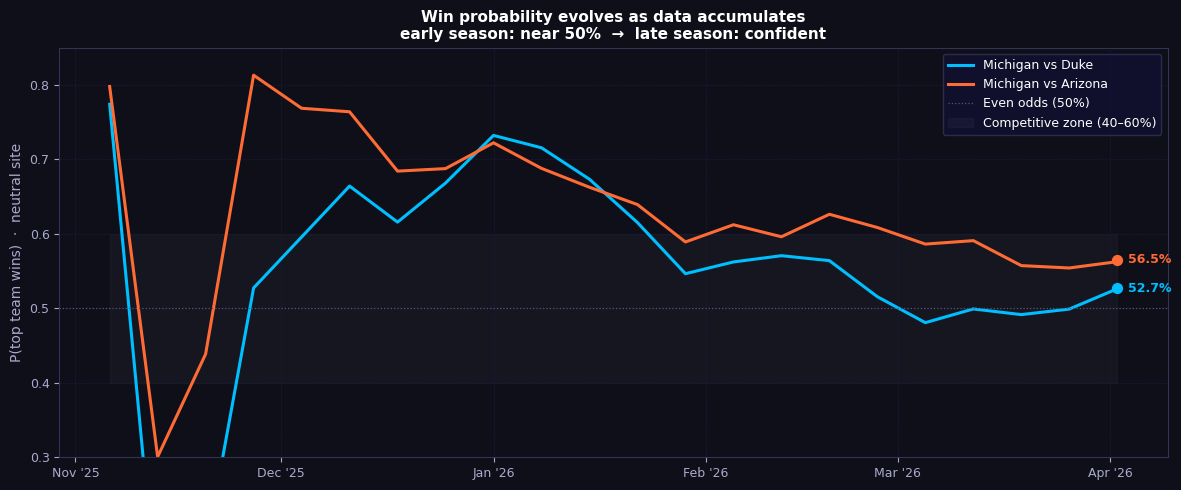

In [6]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
dark_ax(ax, fig)

for i, (_, _, color, label) in enumerate(matchups):
    dates = [p[0] for p in roll[i]]
    probs = [p[1] for p in roll[i]]
    ax.plot(dates, probs, color=color, lw=2.2, label=label)
    ax.scatter(dates[-1], probs[-1], color=color, s=50, zorder=5)
    ax.annotate(f"{probs[-1]:.1%}",
                xy=(dates[-1], probs[-1]),
                xytext=(8, 0), textcoords="offset points",
                color=color, fontsize=9, fontweight="bold",
                va="center", annotation_clip=False)

ax.axhline(0.5, color="#555577", lw=0.9, linestyle=":",
           label="Even odds (50%)")

# Shade the "uncertain" zone near 50%
ax.fill_between(
    [dates[0], dates[-1]], [0.40, 0.40], [0.60, 0.60],
    color="#ffffff", alpha=0.03, label="Competitive zone (40–60%)"
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylim(0.30, 0.85)
ax.set_ylabel("P(top team wins)  ·  neutral site")
ax.set_title(
    "Win probability evolves as data accumulates\n"
    "early season: near 50%  →  late season: confident",
    color="white", fontsize=11, fontweight="bold",
)
ax.legend(labelcolor="white", facecolor="#111133", edgecolor=SPINE, fontsize=9)
plt.tight_layout()
plt.show()

---
## 4 · Conformal calibration diagnostic

The calibration curve in the original notebook tests empirical coverage of the model's Gaussian PIs.  
**Conformal calibration** adds a distribution-free view: compute normalized residuals

$$z_i = \frac{y_i - \hat{y}_i}{\sigma_i^{\text{total}}}, \qquad \sigma_i^{\text{total}} = \sqrt{\sigma_{i,\text{param}}^2 + \sigma_{\text{eff}}^2}$$

Under a correctly-specified Gaussian model, $z_i \overset{\text{iid}}{\sim} \mathcal{N}(0, 1)$.  
Departures from this are immediately interpretable:

| Pattern | Meaning |
|---|---|
| Heavy tails (leptokurtic) | Model overconfident — PIs too narrow |
| Light tails (platykurtic) | Model underconfident — PIs too wide |
| Systematic skew | Directional bias |
| $|z| > 3$ outliers | Specific games the model is surprised by |

In [7]:
actual_cal = np.array([r.pts / r.poss * 100.0 for r in test_rows])

z_scores, coverage = conformal_calibration_scores(
    m2_cal, test_rows,
    actual=actual_cal,
    n_draws=400,
    rng=np.random.default_rng(0),
)

# KS test against N(0,1)
ks_stat, ks_p = kstest(z_scores, "norm")

print(f"z-score summary  (n={len(z_scores):,})")
print(f"  mean   = {z_scores.mean():+.4f}   (should be ≈ 0)")
print(f"  std    = {z_scores.std():.4f}    (should be ≈ 1)")
print(f"  skew   = {float(((z_scores-z_scores.mean())**3).mean()/z_scores.std()**3):+.3f}")
print(f"  excess kurtosis = {float(((z_scores-z_scores.mean())**4).mean()/z_scores.std()**4 - 3):+.3f}")
print(f"  KS stat = {ks_stat:.4f}   p = {ks_p:.4f}")
print()
print(f"{'Level':>8}  {'Nominal':>9}  {'Empirical':>10}  {'Gap':>8}")
print("-" * 42)
for lv, emp in sorted(coverage.items()):
    gap = emp - lv
    flag = "  ← overconfident" if gap < -0.02 else ("  ← underconfident" if gap > 0.02 else "")
    print(f"  {lv:>6.0%}  {lv:>10.1%}  {emp:>10.1%}  {gap:>+8.1%}{flag}")

z-score summary  (n=2,302)
  mean   = +0.1102   (should be ≈ 0)
  std    = 1.1005    (should be ≈ 1)
  skew   = +0.105
  excess kurtosis = -0.123
  KS stat = 0.0571   p = 0.0000

   Level    Nominal   Empirical       Gap
------------------------------------------
     50%       50.0%       46.1%     -3.9%  ← overconfident
     60%       60.0%       55.0%     -5.0%  ← overconfident
     70%       70.0%       64.3%     -5.7%  ← overconfident
     80%       80.0%       75.5%     -4.5%  ← overconfident
     90%       90.0%       86.2%     -3.8%  ← overconfident
     95%       95.0%       92.4%     -2.6%  ← overconfident


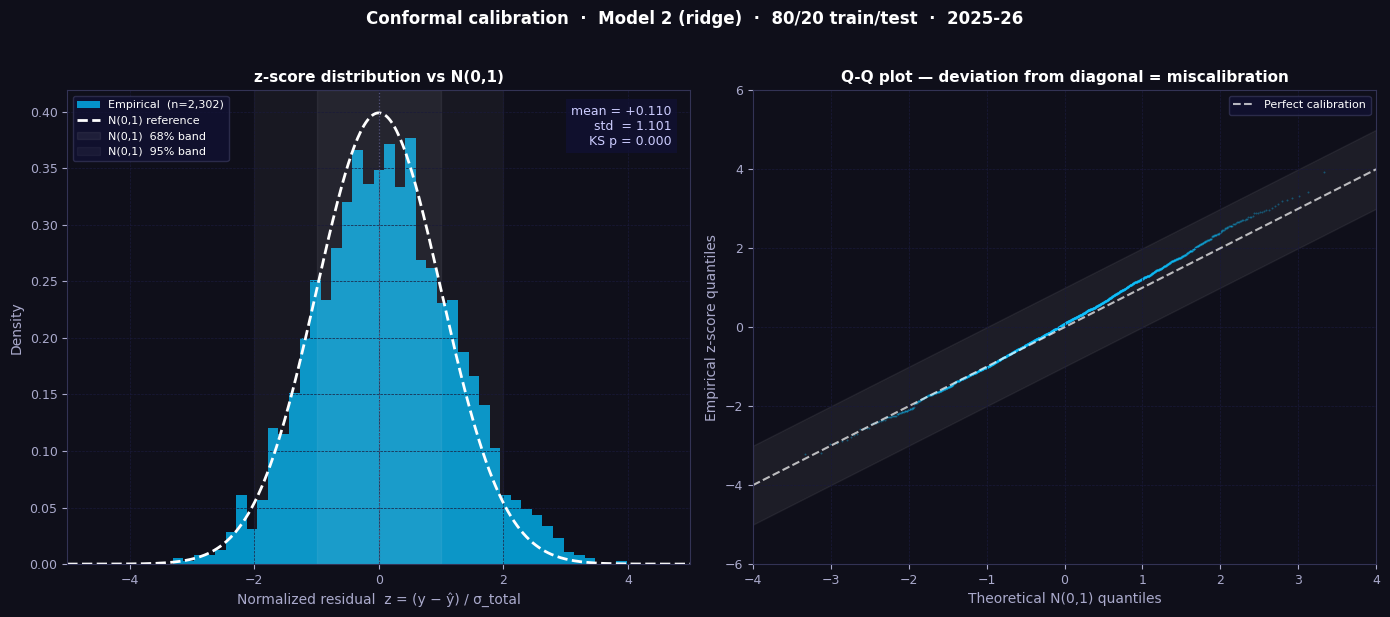

In [8]:
# ── Figure: z-score histogram + Q-Q plot ─────────────────────────────────────
fig, (ax_hist, ax_qq) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
dark_ax(ax_hist); dark_ax(ax_qq)

# --- Histogram vs N(0,1) ---
bins = np.linspace(-5, 5, 60)
ax_hist.hist(z_scores, bins=bins, density=True,
             color=C1, alpha=0.75, edgecolor="none",
             label=f"Empirical  (n={len(z_scores):,})")
xs = np.linspace(-5, 5, 400)
ax_hist.plot(xs, _norm.pdf(xs), color="white", lw=2.0,
             linestyle="--", label="N(0,1) reference")
ax_hist.axvline(0, color="#555577", lw=0.9, linestyle=":")

# Shade ±1σ / ±2σ bands
for lo, hi, alpha, label in [
    (-1, 1, 0.06, "68%"), (-2, 2, 0.04, "95%")
]:
    ax_hist.axvspan(lo, hi, alpha=alpha, color="white",
                   label=f"N(0,1)  {label} band")

ax_hist.text(
    0.97, 0.97,
    f"mean = {z_scores.mean():+.3f}\n"
    f"std  = {z_scores.std():.3f}\n"
    f"KS p = {ks_p:.3f}",
    transform=ax_hist.transAxes, ha="right", va="top",
    color="#ccccff", fontsize=9,
    bbox=dict(fc="#111133", ec="none", alpha=0.80),
)
ax_hist.set_xlabel("Normalized residual  z = (y − ŷ) / σ_total")
ax_hist.set_ylabel("Density")
ax_hist.set_title("z-score distribution vs N(0,1)",
                  color="white", fontsize=11, fontweight="bold")
ax_hist.legend(labelcolor="white", facecolor="#111133",
               edgecolor=SPINE, fontsize=8)
ax_hist.set_xlim(-5, 5)

# --- Q-Q plot ---
sorted_z = np.sort(z_scores)
n = len(sorted_z)
theoretical = _norm.ppf(np.arange(1, n+1) / (n + 1))

ax_qq.scatter(theoretical, sorted_z, s=2, alpha=0.35, color=C1, linewidths=0)
diag = np.array([-4, 4])
ax_qq.plot(diag, diag, color="white", lw=1.5, linestyle="--",
           alpha=0.7, label="Perfect calibration")

# Add ±1 band
ax_qq.fill_between(diag, diag-1, diag+1, alpha=0.06, color="white")

ax_qq.set_xlim(-4, 4); ax_qq.set_ylim(-6, 6)
ax_qq.set_xlabel("Theoretical N(0,1) quantiles")
ax_qq.set_ylabel("Empirical z-score quantiles")
ax_qq.set_title("Q-Q plot — deviation from diagonal = miscalibration",
                color="white", fontsize=11, fontweight="bold")
ax_qq.legend(labelcolor="white", facecolor="#111133",
             edgecolor=SPINE, fontsize=8)

fig.suptitle(
    "Conformal calibration  ·  Model 2 (ridge)  ·  80/20 train/test  ·  2025-26",
    color="white", fontsize=12, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

---
## 5 · Nominal vs empirical coverage

If the model is well-calibrated, the empirical coverage of its Gaussian PIs should match the nominal level at every $\alpha$.  
Gaps here are the same signal as the calibration curve, but summarized in a table the z-scores let us explain.

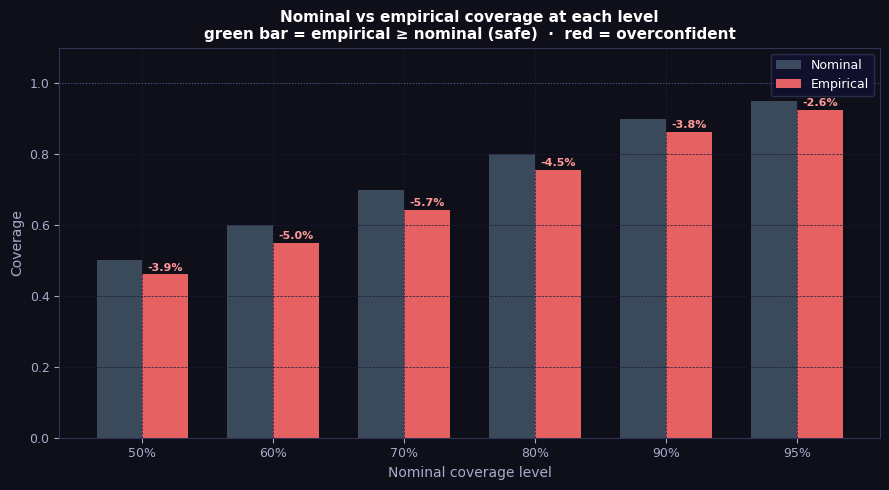

In [9]:
levels  = sorted(coverage.keys())
nominal = np.array(levels)
empirical = np.array([coverage[l] for l in levels])

fig, ax = plt.subplots(figsize=(9, 5))
dark_ax(ax, fig)

x = np.arange(len(levels))
width = 0.35

bars_n = ax.bar(x - width/2, nominal,   width, color="#445566", label="Nominal",   alpha=0.85)
bars_e = ax.bar(x + width/2, empirical, width,
                color=[CA if e >= n else "#ff6b6b"
                       for e, n in zip(empirical, nominal)],
                label="Empirical", alpha=0.90)

# Annotate gaps
for xi, (n, e) in enumerate(zip(nominal, empirical)):
    gap = e - n
    ax.annotate(
        f"{gap:+.1%}",
        xy=(xi + width/2, e + 0.005),
        ha="center", va="bottom", fontsize=8,
        color=CA if gap >= 0 else "#ff9999",
        fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels([f"{l:.0%}" for l in levels], color=TICK)
ax.set_ylim(0, 1.10)
ax.set_xlabel("Nominal coverage level")
ax.set_ylabel("Coverage")
ax.set_title(
    "Nominal vs empirical coverage at each level\n"
    "green bar = empirical ≥ nominal (safe)  ·  red = overconfident",
    color="white", fontsize=11, fontweight="bold",
)
ax.legend(labelcolor="white", facecolor="#111133", edgecolor=SPINE, fontsize=9)
ax.axhline(1.0, color="#555577", lw=0.8, linestyle=":")
plt.tight_layout()
plt.show()

---
## 6 · Which teams surprise the model most?

Sorting by mean absolute z-score per team reveals where the model's uncertainty is systematically wrong:

- **High $|\bar z|$**: model is biased for this team (systematic over or under-prediction)
- **High $\sigma_z$**: high game-to-game variance — the team is genuinely unpredictable, or the model's $\sigma$ is too small for them
- **Both low**: model has the team well-characterized

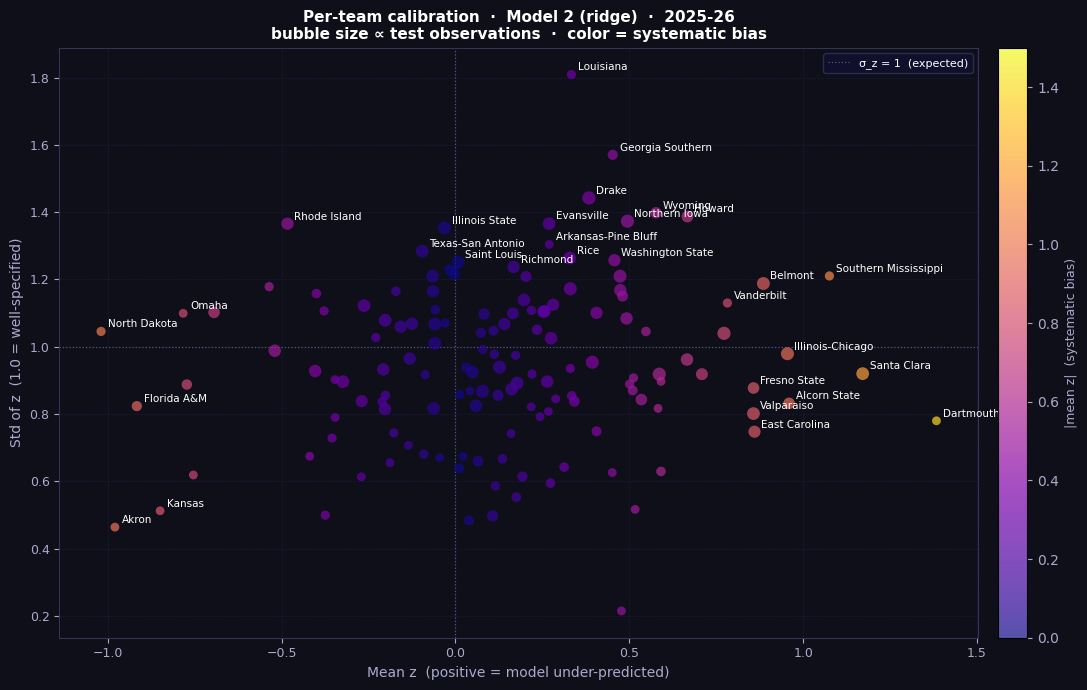


Top 10 most biased teams (by |mean z|):
Team                       Mean z   Std z    n
----------------------------------------------
  Dartmouth               +1.383   0.780     5  (under-pred)
  Santa Clara             +1.171   0.920    22  (under-pred)
  Southern Mississippi    +1.076   1.210     6  (under-pred)
  North Dakota            -1.019   1.045     6  (over-pred)
  Akron                   -0.979   0.464     5  (over-pred)
  Alcorn State            +0.959   0.831    15  (under-pred)
  Illinois-Chicago        +0.955   0.979    24  (under-pred)
  Florida A&M             -0.916   0.823     9  (over-pred)
  Belmont                 +0.886   1.188    23  (under-pred)
  East Carolina           +0.860   0.747    18  (under-pred)


In [10]:
# Per-team z-scores
team_z: dict[int, list[float]] = defaultdict(list)
for row, z in zip(test_rows, z_scores):
    team_z[row.team_id].append(float(z))

# Teams with at least 5 test observations
stats = [
    (tid, np.mean(zs), np.std(zs), len(zs))
    for tid, zs in team_z.items() if len(zs) >= 5
]
stats.sort(key=lambda x: abs(x[1]), reverse=True)  # sort by |mean z|

# ── Scatter: mean z vs std z ──────────────────────────────────────────────────
mean_zs = np.array([s[1] for s in stats])
std_zs  = np.array([s[2] for s in stats])
n_obs   = np.array([s[3] for s in stats])

fig, ax = plt.subplots(figsize=(11, 7))
dark_ax(ax, fig)

sc = ax.scatter(mean_zs, std_zs,
                c=np.abs(mean_zs), cmap="plasma", vmin=0, vmax=1.5,
                s=np.sqrt(n_obs)*18, alpha=0.70, linewidths=0, zorder=3)

cb = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.04)
cb.set_label("|mean z|  (systematic bias)", color=TICK, fontsize=9)
cb.ax.yaxis.set_tick_params(color=TICK)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=TICK)

ax.axvline(0, color="#555577", lw=0.9, linestyle=":")
ax.axhline(1.0, color="#555577", lw=0.9, linestyle=":",
           label="σ_z = 1  (expected)")

# Label the most biased / high-variance teams
label_cutoff = np.percentile(np.abs(mean_zs), 90)
for tid, mz, sz, _ in stats:
    if abs(mz) >= label_cutoff or sz >= np.percentile(std_zs, 90):
        name = team_names.get(tid, str(tid))
        ax.annotate(
            name, xy=(mz, sz), xytext=(5, 3),
            textcoords="offset points", color="white",
            fontsize=7.5, annotation_clip=True,
        )

ax.set_xlabel("Mean z  (positive = model under-predicted)")
ax.set_ylabel("Std of z  (1.0 = well-specified)")
ax.set_title(
    "Per-team calibration  ·  Model 2 (ridge)  ·  2025-26\n"
    "bubble size ∝ test observations  ·  color = systematic bias",
    color="white", fontsize=11, fontweight="bold",
)
ax.legend(labelcolor="white", facecolor="#111133", edgecolor=SPINE, fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nTop 10 most biased teams (by |mean z|):")
print(f"{'Team':<24} {'Mean z':>8} {'Std z':>7} {'n':>4}")
print("-" * 46)
for tid, mz, sz, n in stats[:10]:
    direction = "under-pred" if mz > 0 else "over-pred"
    print(f"  {team_names.get(tid, str(tid)):<22}  {mz:>+6.3f}  {sz:>6.3f}  {n:>4}  ({direction})")

---
## Summary

### Win probability

- Derived directly from the posterior — no new machinery required
- `win_probability(model, t1, t2)` marginalizes over parameter uncertainty and irreducible game noise via a single Normal approximation: $P = \Phi(\bar{\text{margin}} / \sigma_{\text{total}})$
- Early season: all probabilities near 50% (wide posterior)
- Late season: confident separation between elite and mid-tier teams

### Conformal calibration

- z-scores tell us where the model is over- or underconfident, not just whether coverage holds on average
- A well-calibrated model produces z-scores close to $\mathcal{N}(0,1)$: mean ≈ 0, std ≈ 1, light tails
- Per-team analysis turns miscalibration from an aggregate diagnostic into a ranking signal: high $|\bar z|$ teams are those the model has seen the fewest games for, or whose play style the static model systematically misses
- The KS test formalizes whether the Gaussian assumption is warranted — if rejected, the coverage table shows the practical magnitude of the violation

Both outputs flow from the same posterior object. No separate calibration step needed.